## Problem Statement

The primary objective of this analysis is to develop a classification model capable of accurately predicting whether a customer will `purchase` a product (binary classification). The model should effectively handle potential class imbalance and provide reliable performance metrics for evaluation.

In [ ]:
'''
!pip install lazypredict
!pip install mlflow
'''

'\n!pip install lazypredict\n!pip install mlflow\n'

In [ ]:
import pandas as pd
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC, NuSVC
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.model_selection import cross_validate
from sklearn.linear_model import RidgeClassifier, SGDClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv('/content/data.csv')
df = df.drop(columns=['m1_consideration'])

X = df.drop('purchased', axis=1)
y = df['purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LazyClassifier(verbose=0, ignore_warnings=True)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
NearestCentroid                    0.72           0.761029  0.830882   
GaussianNB                         0.76           0.757353  0.816176   
KNeighborsClassifier               0.80           0.753676  0.731618   
NuSVC                              0.80           0.753676  0.750000   
SVC                                0.80           0.753676  0.794118   
SGDClassifier                      0.68           0.731618  0.683824   
RandomForestClassifier             0.76           0.724265  0.772059   
BernoulliNB                        0.76           0.724265  0.816176   
ExtraTreesClassifier               0.72           0.694853  0.761029   
LGBMClassifier                     0.76           0.691176  0.838235   
PassiveAggressiveClassifier        0.64           0.669118  0.757353   
ExtraTreeClassifier                0.68           0.665441  0.66

In [ ]:
models.to_csv('model_comparison_results.csv')

In [ ]:
# top models identified by LazyPredict
top_models = {
    'NearestCentroid': NearestCentroid(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'NuSVC': NuSVC(),
    'SVC': SVC(),
    'GaussianNB': GaussianNB(),
    'SGDClassifier': SGDClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'BernoulliNB': BernoulliNB(),
    'LGBMClassifier': LGBMClassifier(),
    'ExtraTreesClassifier': ExtraTreesClassifier()
}

# 10-Fold Cross Validation
for name, model in top_models.items():
    # cross_validate to get multiple scores (accuracy and f1)
    cv_results = cross_validate(model, X, y, cv=10, scoring=['precision'])
    precision_scores = cv_results['test_precision']
    print(f"{name} CV Average Precision: {precision_scores.mean():.4f} (+/- {precision_scores.std():.4f})")
    print("\n")

NearestCentroid CV Average Precision: 0.7518 (+/- 0.1342)


KNeighborsClassifier CV Average Precision: 0.6615 (+/- 0.0703)


NuSVC CV Average Precision: 0.6806 (+/- 0.0852)


SVC CV Average Precision: 0.6604 (+/- 0.0397)


GaussianNB CV Average Precision: 0.7831 (+/- 0.0878)


SGDClassifier CV Average Precision: 0.7532 (+/- 0.1158)


RandomForestClassifier CV Average Precision: 0.7164 (+/- 0.0561)


BernoulliNB CV Average Precision: 0.7913 (+/- 0.0755)


LGBMClassifier CV Average Precision: 0.7548 (+/- 0.0565)


ExtraTreesClassifier CV Average Precision: 0.7409 (+/- 0.1005)




In [ ]:
for name, model in top_models.items():
    results = cross_validate(model, X, y, cv=10, scoring=['precision', 'f1'], return_train_score=True)

    precision_scores_test = results['test_precision']
    f1_scores_test = results['test_f1']
    precision_scores_train = results['train_precision']
    f1_scores_train = results['train_f1']

    print(f"{name} CV Average Test Precision: {precision_scores_test.mean():.4f} (+/- {precision_scores_test.std():.4f})")
    print(f"{name} CV Average Test F1 Score: {f1_scores_test.mean():.4f} (+/- {f1_scores_test.std():.4f})")
    print(f"{name} CV Average Train Precision: {precision_scores_train.mean():.4f} (+/- {precision_scores_train.std():.4f})")
    print(f"{name} CV Average Train F1 Score: {f1_scores_train.mean():.4f} (+/- {f1_scores_train.std():.4f})")
    print("\n")

NearestCentroid CV Average Test Precision: 0.7518 (+/- 0.1342)
NearestCentroid CV Average Test F1 Score: 0.6370 (+/- 0.1457)
NearestCentroid CV Average Train Precision: 0.7375 (+/- 0.0157)
NearestCentroid CV Average Train F1 Score: 0.6625 (+/- 0.0183)


KNeighborsClassifier CV Average Test Precision: 0.6615 (+/- 0.0703)
KNeighborsClassifier CV Average Test F1 Score: 0.6978 (+/- 0.1164)
KNeighborsClassifier CV Average Train Precision: 0.7510 (+/- 0.0160)
KNeighborsClassifier CV Average Train F1 Score: 0.8255 (+/- 0.0134)


NuSVC CV Average Test Precision: 0.6806 (+/- 0.0852)
NuSVC CV Average Test F1 Score: 0.6909 (+/- 0.1637)
NuSVC CV Average Train Precision: 0.8633 (+/- 0.0156)
NuSVC CV Average Train F1 Score: 0.9075 (+/- 0.0114)


SVC CV Average Test Precision: 0.6604 (+/- 0.0397)
SVC CV Average Test F1 Score: 0.7823 (+/- 0.0228)
SVC CV Average Train Precision: 0.6822 (+/- 0.0143)
SVC CV Average Train F1 Score: 0.8053 (+/- 0.0099)


GaussianNB CV Average Test Precision: 0.7831 (+/- 0.

GaussianNB

BernoulliNB

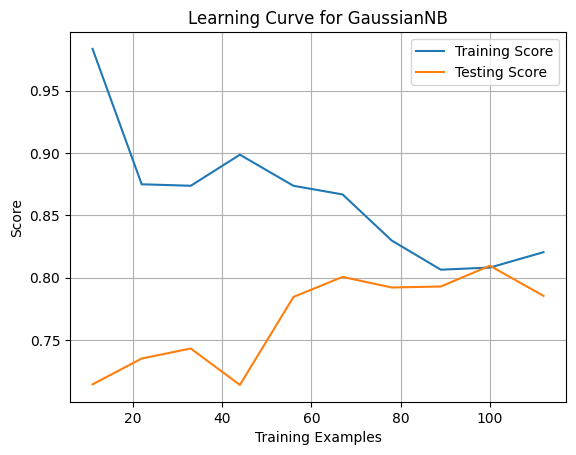

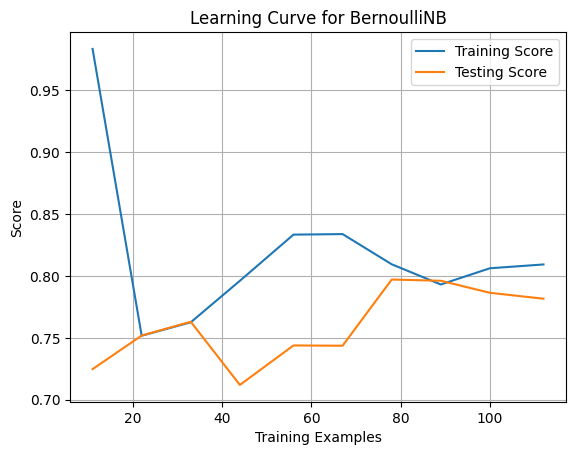

In [ ]:
def plot_learning_curve(model, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=10, scoring='precision', train_sizes=np.linspace(0.1, 1.0, 10)
    )

    plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Testing Score')
    plt.title(f"Learning Curve for {model.__class__.__name__}")
    plt.xlabel("Training Examples")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curve(GaussianNB(), X, y)
plot_learning_curve(BernoulliNB(), X, y)

In [ ]:
# parameter grid of BernoulliNB
param_grid_nb = {
    'alpha': [0.01, 0.1, 0.05, 1.0, 2.0, 10.0], # Controls smoothing
    'binarize': [0.0, 0.1, 0.5, 1.0],           # Threshold for features
    'fit_prior': [True, False]
}

grid_nb = GridSearchCV(BernoulliNB(), param_grid_nb, cv=5, scoring='precision', n_jobs=-1)
grid_nb.fit(X_train, y_train)

print("BernoulliNB Best Params:", grid_nb.best_params_)
print("BernoulliNB Best Score:", grid_nb.best_score_)

BernoulliNB Best Params: {'alpha': 0.01, 'binarize': 0.1, 'fit_prior': False}
BernoulliNB Best Score: 0.8638461538461538


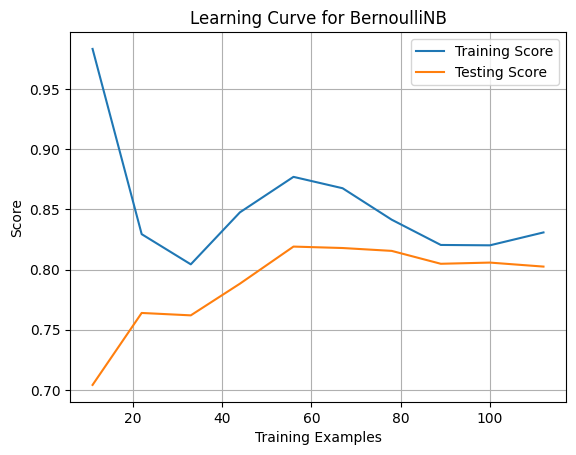

In [ ]:
# Plot learning curve for updated BernoulliNB
plot_learning_curve(BernoulliNB(alpha=0.01, binarize=0.1, fit_prior=False), X, y)

In [ ]:
# parameter grid of GaussianNB
param_grid_GaussianNB = {
    'var_smoothing': np.logspace(0, -9, num=100) # Smoothes the variance for stability
}

grid_ridge_cl = GridSearchCV(GaussianNB(), param_grid_GaussianNB, cv=5, scoring='precision', n_jobs=-1)
grid_ridge_cl.fit(X_train, y_train)

print("Ridge Best Params:", grid_ridge_cl.best_params_)
print("Ridge Best Score:", grid_ridge_cl.best_score_)

Ridge Best Params: {'var_smoothing': np.float64(0.0003511191734215131)}
Ridge Best Score: 0.7807369101486749


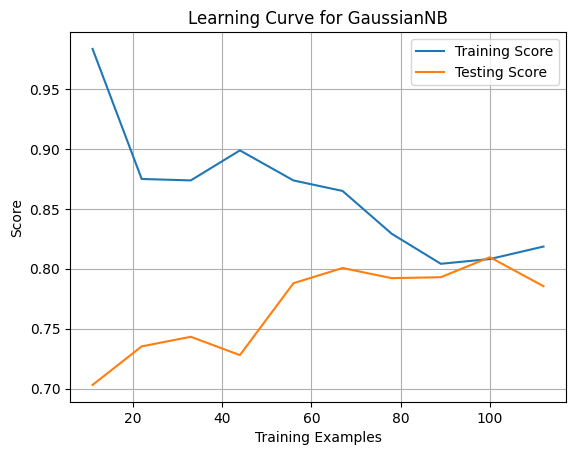

In [ ]:
# Plot learning curve for updated RidgeClassifier
plot_learning_curve(GaussianNB(var_smoothing = 0.0003511191734215131), X, y)

In [ ]:
final_models = {
    'BernoulliNB': BernoulliNB(alpha=0.01, binarize=0.1, fit_prior=False),
    'GaussianNB': GaussianNB(var_smoothing = 0.0003511191734215131)
}


# 10-Fold Cross Validation
for name, model in final_models.items():
    # cross_validate to get multiple scores (precision and f1)
    cv_results = cross_validate(model, X, y, cv=10, scoring=['precision', 'f1'])
    Precision_scores = cv_results['test_precision']
    f1_scores = cv_results['test_f1']
    print(f"{name} CV Average Precision: {Precision_scores.mean():.4f} (+/- {Precision_scores.std():.4f})")
    print(f"{name} CV Average F1 Score: {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
    y_pred = model.fit(X_train, y_train).predict(X_test)
    print(classification_report(y_test, y_pred, target_names=['Not Purchased', 'Purchased']))
    print("\n")

BernoulliNB CV Average Precision: 0.8024 (+/- 0.0636)
BernoulliNB CV Average F1 Score: 0.7852 (+/- 0.0890)
               precision    recall  f1-score   support

Not Purchased       0.55      0.75      0.63         8
    Purchased       0.86      0.71      0.77        17

     accuracy                           0.72        25
    macro avg       0.70      0.73      0.70        25
 weighted avg       0.76      0.72      0.73        25



GaussianNB CV Average Precision: 0.7855 (+/- 0.0894)
GaussianNB CV Average F1 Score: 0.7881 (+/- 0.0912)
               precision    recall  f1-score   support

Not Purchased       0.60      0.75      0.67         8
    Purchased       0.87      0.76      0.81        17

     accuracy                           0.76        25
    macro avg       0.73      0.76      0.74        25
 weighted avg       0.78      0.76      0.77        25





In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score

# 1. Initialize the top 2 models with your best parameters
clf1 = BernoulliNB(alpha=0.01, binarize=0.1, fit_prior=False)
clf2 = GaussianNB(var_smoothing = 0.0003511191734215131)

# 2. Create the Ensemble
# 'hard' voting uses the predicted labels; 'soft' requires predict_proba
ensemble_model = VotingClassifier(
    estimators=[
        ('bnb', clf1),
        ('ridge', clf2)
    ],
    voting='hard'
)

# 3. Evaluate with Cross-Validation
cv_Precision = cross_val_score(ensemble_model, X, y, cv=5, scoring='precision')
cv_f1 = cross_val_score(ensemble_model, X, y, cv=5, scoring='f1_weighted')

print(f"Ensemble CV Precision: {cv_Precision.mean():.4f} (+/- {cv_Precision.std():.4f})")
print(f"Ensemble CV F1 Score: {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")

# 4. Final Fit
ensemble_model.fit(X_train, y_train)


Ensemble CV Precision: 0.8221 (+/- 0.0566)
Ensemble CV F1 Score: 0.7294 (+/- 0.0611)


VotingClassifier(estimators=[('bnb',
                              BernoulliNB(alpha=0.01, binarize=0.1,
                                          fit_prior=False)),
                             ('ridge',
                              GaussianNB(var_smoothing=0.0003511191734215131))])

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score

# Soft Voting Ensemble
ensemble = VotingClassifier(
    estimators=[
        ('bnb', clf1),
        ('ridge', clf2)
    ]
)

# Search for the best weighting balance
# (e.g., [1, 1] is equal, [2, 1] gives double weight to BernoulliNB)
param_grid = {'weights': [[1, 1], [1.2, 1], [1.5, 1], [1, 1.2], [1, 1.5]],
              'voting': ['soft','hard']}

grid_search = GridSearchCV(ensemble, param_grid, cv=5, scoring=['precision', 'f1'], refit='precision')
grid_search.fit(X, y)

print(f"Best Weights: {grid_search.best_params_}")
print(f"Best Ensemble Precision: {grid_search.best_score_:.4f} (+/- {grid_search.cv_results_['std_test_precision'][grid_search.best_index_]:.4f})")

y_pred = grid_search.best_estimator_.fit(X_train, y_train).predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Not Purchased', 'Purchased']))

Best Weights: {'voting': 'hard', 'weights': [1, 1]}
Best Ensemble Precision: 0.8221 (+/- 0.0566)
               precision    recall  f1-score   support

Not Purchased       0.50      0.75      0.60         8
    Purchased       0.85      0.65      0.73        17

     accuracy                           0.68        25
    macro avg       0.67      0.70      0.67        25
 weighted avg       0.74      0.68      0.69        25



In [ ]:
from sklearn.model_selection import GridSearchCV

# the ensemble
ensemble_soft = VotingClassifier(
    estimators=[
        ('bnb', clf1),
        ('ridge', clf2)
    ],
    voting='soft'
)

# Search for the best weighting balance
# (e.g., [1, 1] is equal, [2, 1] gives double weight to BernoulliNB)
param_grid = {'weights': [[1, 1], [1.2, 1], [1.5, 1], [1, 1.2], [1, 1.5]]}

grid_search_soft = GridSearchCV(ensemble_soft, param_grid, cv=5, scoring=['precision', 'f1'], refit='precision')
grid_search_soft.fit(X, y)

print(f"Best Weights: {grid_search_soft.best_params_}")
print(f"Best Ensemble Precision: {grid_search_soft.best_score_:.4f} (+/- {grid_search_soft.cv_results_['std_test_precision'][grid_search_soft.best_index_]:.4f})")

y_pred = grid_search_soft.best_estimator_.fit(X_train, y_train).predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Not Purchased', 'Purchased']))

Best Weights: {'weights': [1, 1]}
Best Ensemble Precision: 0.8122 (+/- 0.0374)
               precision    recall  f1-score   support

Not Purchased       0.60      0.75      0.67         8
    Purchased       0.87      0.76      0.81        17

     accuracy                           0.76        25
    macro avg       0.73      0.76      0.74        25
 weighted avg       0.78      0.76      0.77        25



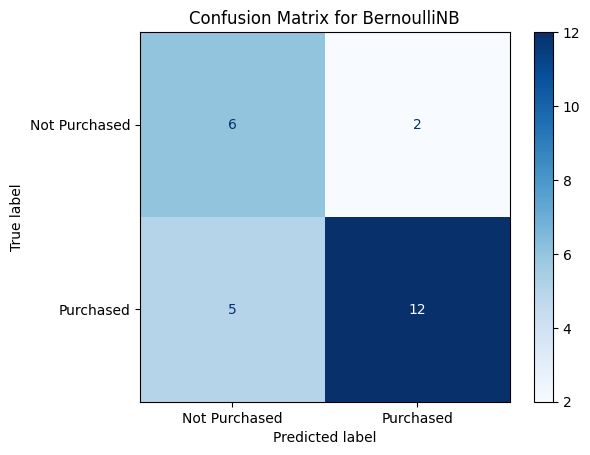

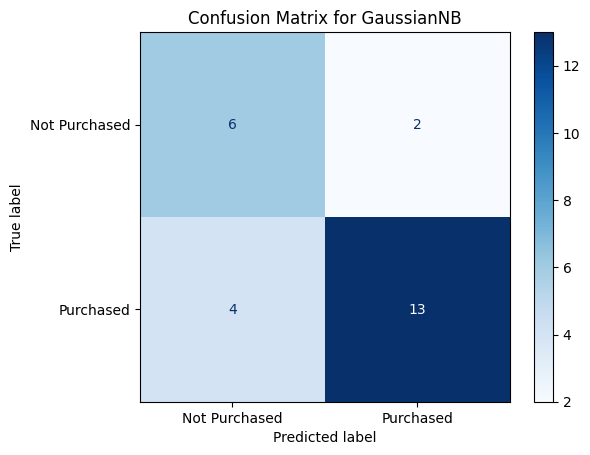

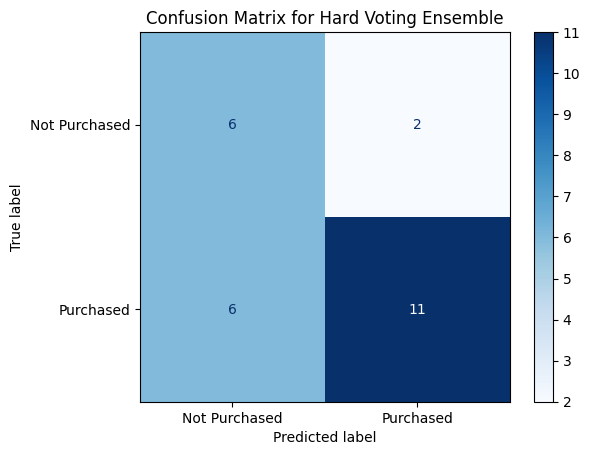

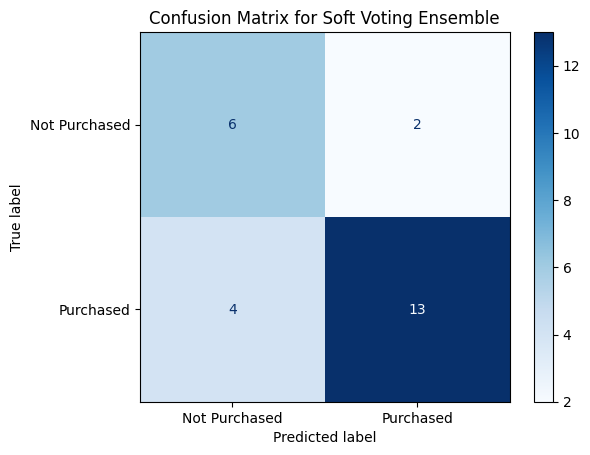

In [ ]:
clf1 = BernoulliNB(alpha=0.01, binarize=0.1, fit_prior=False)
clf2 = GaussianNB(var_smoothing = 0.0003511191734215131)

# Ensure grid_search and grid_search_soft are available from previous executions
# Best hard voting ensemble (from grid_search, which found 'hard' voting as best)
best_hard_ensemble = grid_search.best_estimator_

# Best soft voting ensemble (from grid_search_soft, explicitly for soft voting)
best_soft_ensemble = grid_search_soft.best_estimator_

models_to_plot = {
    'BernoulliNB': clf1,
    'GaussianNB': clf2,
    'Hard Voting Ensemble': best_hard_ensemble,
    'Soft Voting Ensemble': best_soft_ensemble
}

for name, model in models_to_plot.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

**Final Model without weights.**

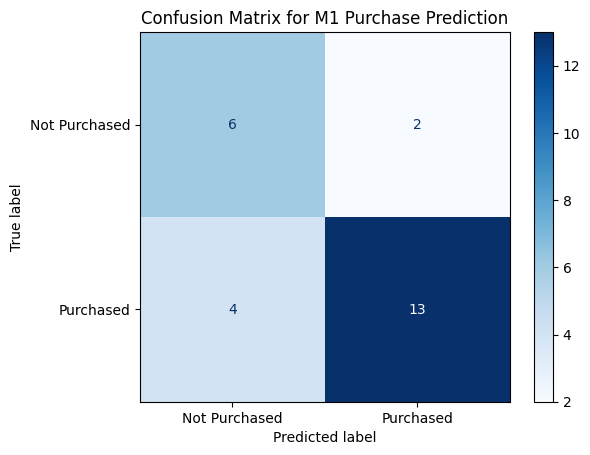

               precision    recall  f1-score   support

Not Purchased       0.60      0.75      0.67         8
    Purchased       0.87      0.76      0.81        17

     accuracy                           0.76        25
    macro avg       0.73      0.76      0.74        25
 weighted avg       0.78      0.76      0.77        25



In [ ]:
final_model=GaussianNB(var_smoothing = 0.0003511191734215131)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for M1 Purchase Prediction")
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Purchased', 'Purchased']))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:71: FutureWarning: `fit_params` is deprecated and will be removed in version {version}. Pass parameters via `params` instead.
  warnings.warn(


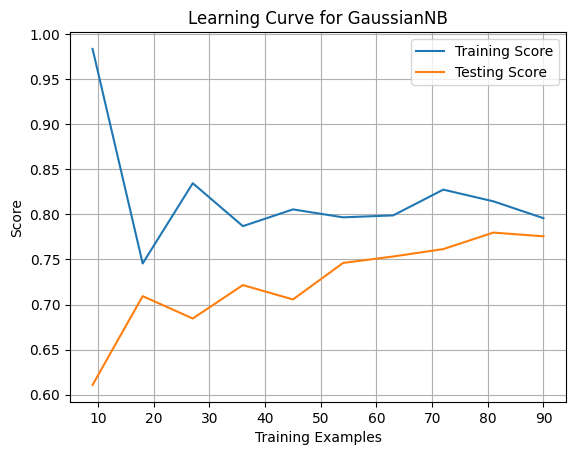

In [ ]:
plot_learning_curve(GaussianNB(var_smoothing = 0.0003511191734215131), X_train, y_train)

**Final Model**

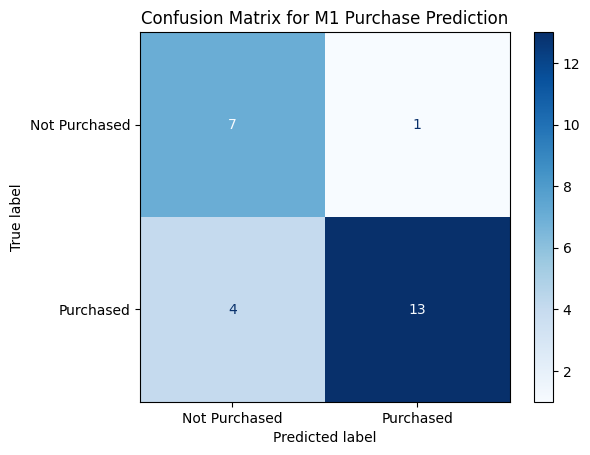

               precision    recall  f1-score   support

Not Purchased       0.64      0.88      0.74         8
    Purchased       0.93      0.76      0.84        17

     accuracy                           0.80        25
    macro avg       0.78      0.82      0.79        25
 weighted avg       0.84      0.80      0.81        25



In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.utils.class_weight import compute_sample_weight

# Calculate weights based on the 'balanced' heuristic
weights = compute_sample_weight('balanced', y_train)

final_model=GaussianNB(var_smoothing = 0.0003511191734215131)
final_model.fit(X_train, y_train, sample_weight=weights)

y_pred = final_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for M1 Purchase Prediction")
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Purchased', 'Purchased']))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:71: FutureWarning: `fit_params` is deprecated and will be removed in version {version}. Pass parameters via `params` instead.
  warnings.warn(


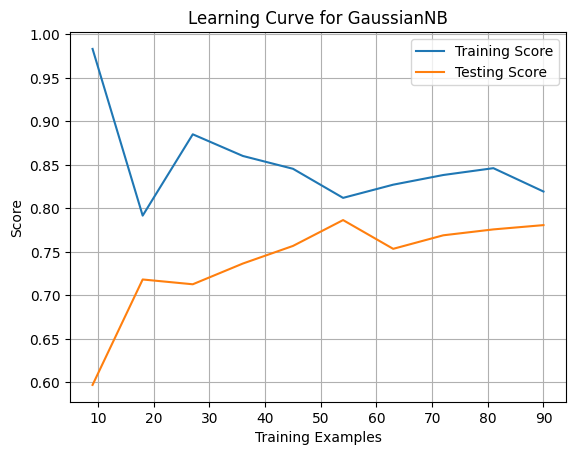

In [ ]:
def plot_learning_curve(model, X, y, sample_weight=None):
    fit_params = {}
    if sample_weight is not None:
        fit_params['sample_weight'] = sample_weight

    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=10, scoring='precision', train_sizes=np.linspace(0.1, 1.0, 10), fit_params=fit_params
    )

    plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Testing Score')
    plt.title(f"Learning Curve for {model.__class__.__name__}")
    plt.xlabel("Training Examples")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curve(GaussianNB(var_smoothing = 0.0003511191734215131), X_train, y_train, sample_weight=weights)

## Solution Summary

The notebook follows a comprehensive machine learning workflow:

1.  **Initial Model Exploration**: `LazyPredict` was used to quickly evaluate a wide range of classification algorithms, providing an initial performance benchmark across various models.
2.  **Top Model Identification**: Based on `LazyPredict` results and subsequent 10-fold cross-validation, `GaussianNB` and `BernoulliNB` were identified as promising candidates due to their good balance of precision and F1-scores.
3.  **Hyperparameter Tuning**: `GridSearchCV` was employed to optimize the hyperparameters for both `BernoulliNB` and `GaussianNB` to further enhance their performance. For `BernoulliNB`, the best parameters were `{'alpha': 0.01, 'binarize': 0.1, 'fit_prior': False}`. For `GaussianNB`, `{'var_smoothing': 0.0003511191734215131}` was found to be optimal.
4.  **Ensemble Modeling**: Attempts were made to combine the top models using `VotingClassifier` (both 'hard' and 'soft' voting). While hard voting showed some promise, the tuned individual `GaussianNB` model ultimately performed competitively.
5.  **Addressing Class Imbalance**: The final step involved incorporating `sample_weight` using `compute_sample_weight('balanced')` during the training of the `GaussianNB` model. This significantly improved the model's ability to correctly classify both classes, particularly enhancing the recall for the 'Not Purchased' class.
6.  **Performance Evaluation**: Learning curves and confusion matrices were used to visualize model performance and stability, with `precision`, `f1-score`, and `recall` as key metrics.

## Final Model

The final selected model is a **Gaussian Naive Bayes classifier** with optimized hyperparameters and trained with `balanced` sample weights to address class imbalance. Its specific configuration is:

*   **Model**: `GaussianNB`
*   **Hyperparameter**: `var_smoothing = 0.0003511191734215131`
*   **Training Strategy**: Trained with `sample_weight` computed as `'balanced'` using `compute_sample_weight` to give more importance to the minority class during training.

This final model achieved the following performance on the test set:

```
               precision    recall  f1-score   support

Not Purchased       0.64      0.88      0.74         8
    Purchased       0.93      0.76      0.84        17

     accuracy                           0.80        25
    macro avg       0.78      0.82      0.79        25
 weighted avg       0.84      0.80      0.81        25
```

This shows a good balance of precision and recall for both classes, indicating robust performance for purchase prediction.